# Notebook 01: fastMRI Data Exploration

**CS231N Final Project — FA-KGD: Frequency-Adaptive Kalman-Guided Diffusion**

This notebook explores the fastMRI knee singlecoil dataset:
- HDF5 file structure and metadata
- k-space visualization (frequency domain ↔ image domain)
- Dataset statistics (slice counts, image dimensions)
- Undersampling masks and aliasing artifacts at different acceleration factors

In [1]:
import sys
sys.path.insert(0, '..')

import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

## 1.1 Inspect a single HDF5 file

Each `.h5` file is one MRI volume (one patient scan) with multiple 2D slices.

In [2]:
DATA_DIR = Path('../data/singlecoil_test')
files = sorted(DATA_DIR.glob('*.h5'))
print(f'Number of volumes: {len(files)}')
print(f'First few files: {[f.name for f in files[:5]]}')

Number of volumes: 108
First few files: ['file1000022.h5', 'file1000036.h5', 'file1000055.h5', 'file1000056.h5', 'file1000063.h5']


In [3]:
# Open one file and inspect its contents
sample_file = files[0]
with h5py.File(sample_file, 'r') as hf:
    print(f'File: {sample_file.name}')
    print(f'Keys: {list(hf.keys())}')
    print()
    for key in hf.keys():
        print(f'  {key}: shape={hf[key].shape}, dtype={hf[key].dtype}')
    print()
    # Attributes (metadata)
    print('Attributes:')
    for attr_name, attr_val in hf.attrs.items():
        print(f'  {attr_name}: {attr_val}')

File: file1000022.h5
Keys: ['ismrmrd_header', 'kspace', 'mask']

  ismrmrd_header: shape=(), dtype=object
  kspace: shape=(37, 640, 368), dtype=complex64
  mask: shape=(368,), dtype=bool

Attributes:
  acceleration: 8
  acquisition: CORPDFS_FBK
  num_low_frequency: 15
  patient_id: e24dd3dc05085077e65af05fc5d4c439e5e338e58926c4f344274080bd7f7cdd


## 1.2 Dataset statistics

Let's get an overview of the test set: number of slices per volume, k-space dimensions, etc.

In [4]:
stats = []
for f in files:
    with h5py.File(f, 'r') as hf:
        kspace = hf['kspace']
        stats.append({
            'file': f.name,
            'num_slices': kspace.shape[0],
            'height': kspace.shape[1],
            'width': kspace.shape[2],
            'dtype': str(kspace.dtype),
        })

num_slices = [s['num_slices'] for s in stats]
heights = set(s['height'] for s in stats)
widths = set(s['width'] for s in stats)

print(f'Total volumes: {len(stats)}')
print(f'Total slices: {sum(num_slices)}')
print(f'Slices per volume: min={min(num_slices)}, max={max(num_slices)}, mean={np.mean(num_slices):.1f}')
print(f'Unique heights: {heights}')
print(f'Unique widths: {widths}')
print(f'dtype: {stats[0]["dtype"]}')

Total volumes: 108
Total slices: 3903
Slices per volume: min=30, max=48, mean=36.1
Unique heights: {640}
Unique widths: {320, 544, 322, 356, 368, 400, 594, 372}
dtype: complex64


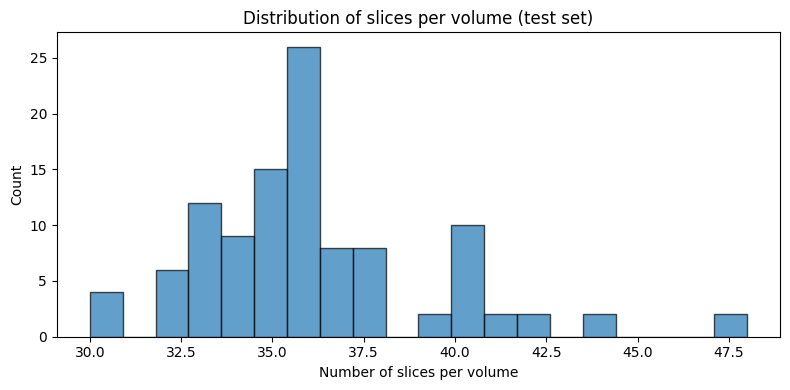

In [5]:
# Distribution of slices per volume
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(num_slices, bins=20, edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of slices per volume')
ax.set_ylabel('Count')
ax.set_title('Distribution of slices per volume (test set)')
plt.tight_layout()
plt.show()

## 1.3 Visualize k-space and image domain

k-space is the raw frequency-domain data acquired by the MRI scanner.
Applying a 2D inverse FFT converts k-space → image domain.

In [6]:
# Load a single slice
with h5py.File(files[0], 'r') as hf:
    kspace_vol = hf['kspace'][()]

# Pick a middle slice (usually has the most anatomy)
mid_slice = kspace_vol.shape[0] // 2
kspace = kspace_vol[mid_slice]  # complex128 (H, W)

print(f'k-space shape: {kspace.shape}, dtype: {kspace.dtype}')
print(f'k-space value range: |min|={np.abs(kspace).min():.2e}, |max|={np.abs(kspace).max():.2e}')

k-space shape: (640, 368), dtype: complex64
k-space value range: |min|=0.00e+00, |max|=7.11e-03


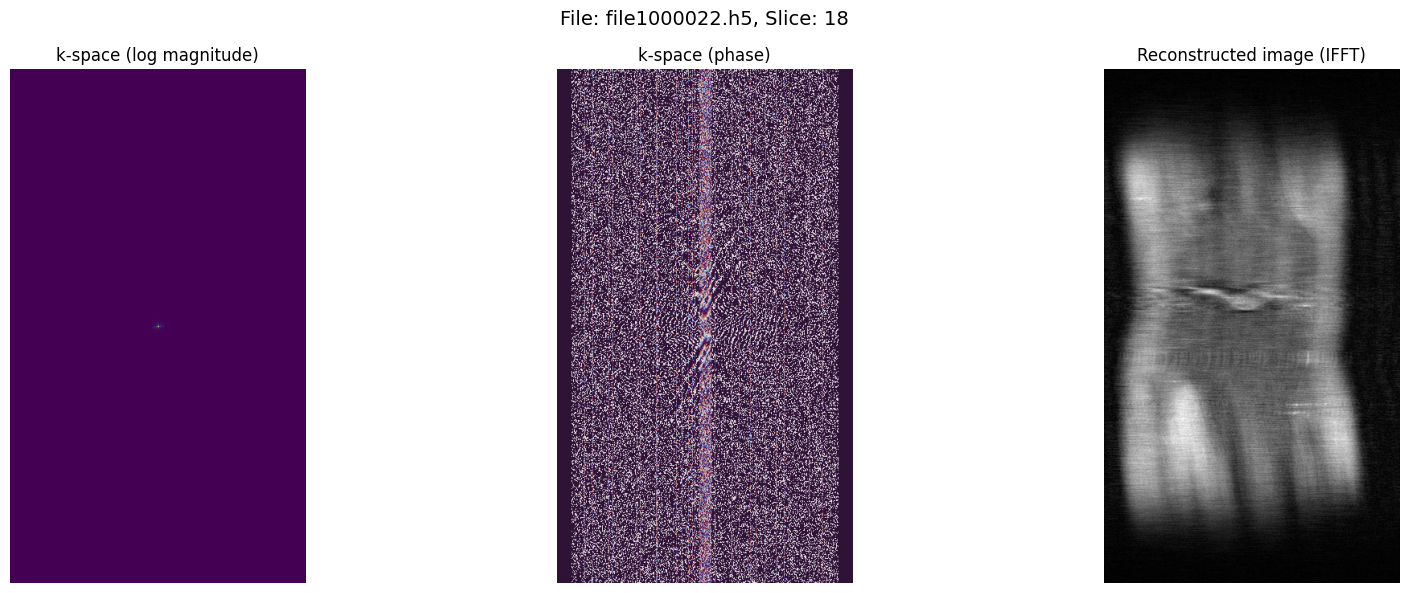

In [7]:
# Reconstruct image from k-space via centered inverse FFT
image = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace)))
image_mag = np.abs(image)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# k-space (log magnitude for visibility)
axes[0].imshow(np.log1p(np.abs(kspace)), cmap='viridis')
axes[0].set_title('k-space (log magnitude)')
axes[0].axis('off')

# k-space phase
axes[1].imshow(np.angle(kspace), cmap='twilight')
axes[1].set_title('k-space (phase)')
axes[1].axis('off')

# Reconstructed image
axes[2].imshow(image_mag, cmap='gray')
axes[2].set_title('Reconstructed image (IFFT)')
axes[2].axis('off')

plt.suptitle(f'File: {files[0].name}, Slice: {mid_slice}', fontsize=14)
plt.tight_layout()
plt.show()

## 1.4 Browse slices through a volume

View multiple slices to understand the 3D anatomy captured.

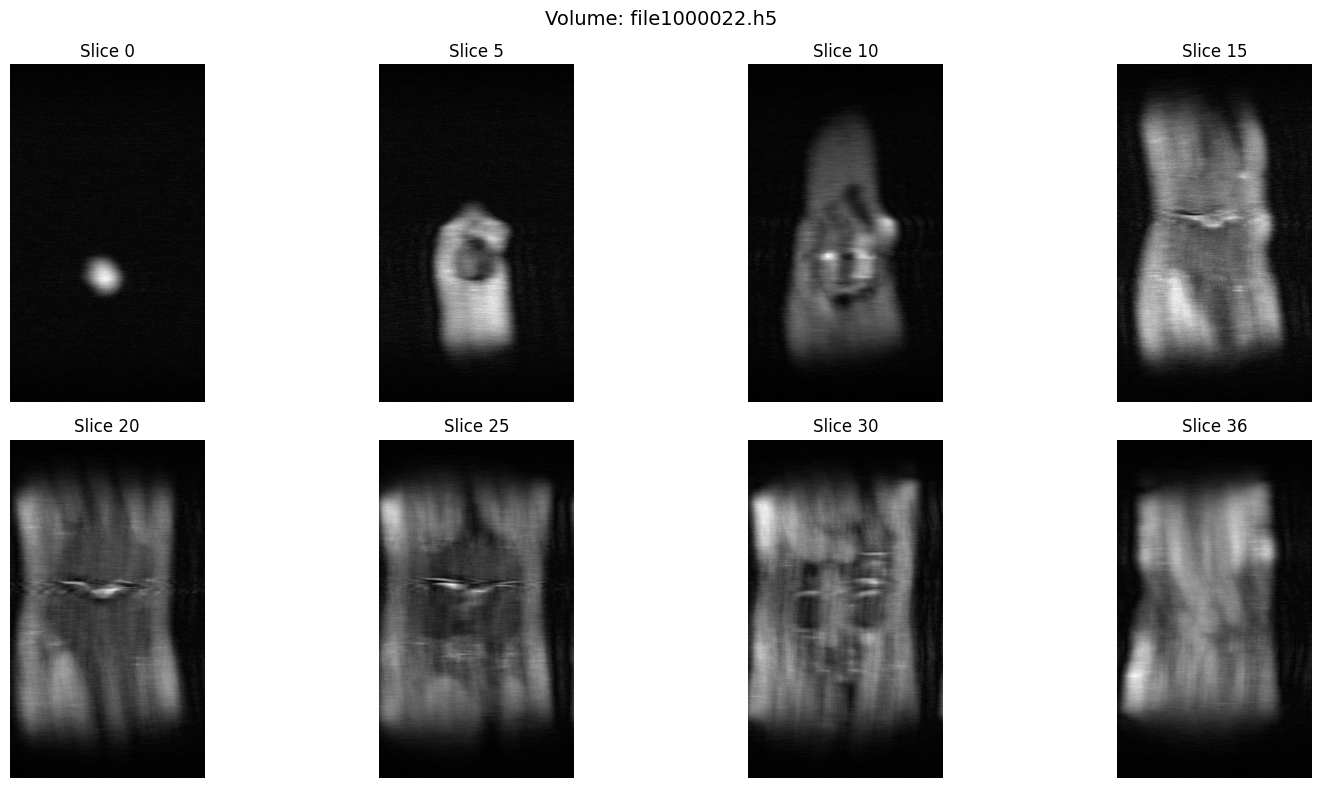

In [8]:
n_show = min(8, kspace_vol.shape[0])
indices = np.linspace(0, kspace_vol.shape[0] - 1, n_show, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, idx in zip(axes.flat, indices):
    img = np.abs(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace_vol[idx]))))
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Slice {idx}')
    ax.axis('off')

plt.suptitle(f'Volume: {files[0].name}', fontsize=14)
plt.tight_layout()
plt.show()

## 1.5 Undersampling and aliasing

MRI acceleration works by acquiring fewer k-space lines.
This causes **aliasing artifacts** in the reconstructed image.
The goal of our model is to remove these artifacts.

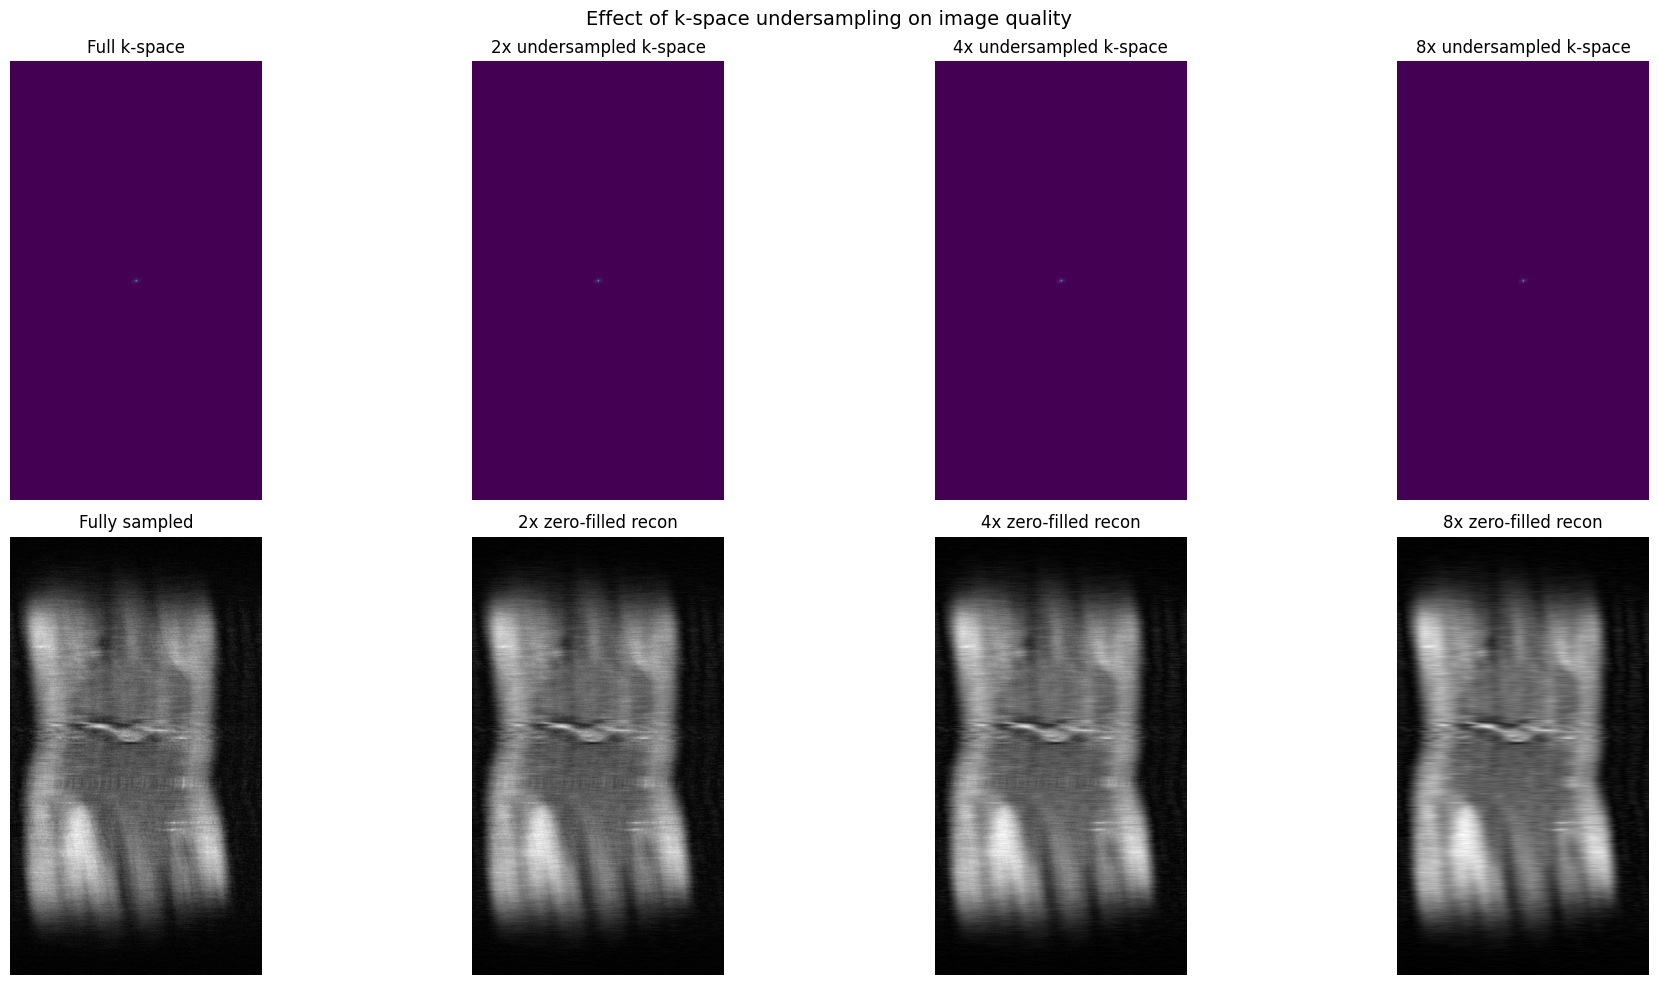

In [9]:
import torch
from src.data.transforms import create_mask, ifft2c

kspace_torch = torch.from_numpy(kspace).unsqueeze(0)  # (1, H, W) complex

accelerations = [2, 4, 8]
fig, axes = plt.subplots(2, len(accelerations) + 1, figsize=(20, 10))

# Fully sampled
full_img = torch.abs(ifft2c(kspace_torch)).squeeze().numpy()
axes[0, 0].imshow(np.log1p(np.abs(kspace)), cmap='viridis')
axes[0, 0].set_title('Full k-space')
axes[0, 0].axis('off')
axes[1, 0].imshow(full_img, cmap='gray')
axes[1, 0].set_title('Fully sampled')
axes[1, 0].axis('off')

for i, acc in enumerate(accelerations):
    mask = create_mask(kspace.shape[-1], center_fraction=0.08, acceleration=acc, seed=42)
    # mask shape: (1, W) -> broadcast over H
    masked_kspace = kspace_torch * mask.unsqueeze(0)  # (1, H, W)
    
    # Show masked k-space
    axes[0, i+1].imshow(np.log1p(np.abs(masked_kspace.squeeze().numpy())), cmap='viridis')
    axes[0, i+1].set_title(f'{acc}x undersampled k-space')
    axes[0, i+1].axis('off')
    
    # Reconstruct
    recon = torch.abs(ifft2c(masked_kspace)).squeeze().numpy()
    axes[1, i+1].imshow(recon, cmap='gray')
    axes[1, i+1].set_title(f'{acc}x zero-filled recon')
    axes[1, i+1].axis('off')

plt.suptitle('Effect of k-space undersampling on image quality', fontsize=14)
plt.tight_layout()
plt.show()

## 1.6 Mask visualization

Visualize what the undersampling masks look like for different acceleration factors.

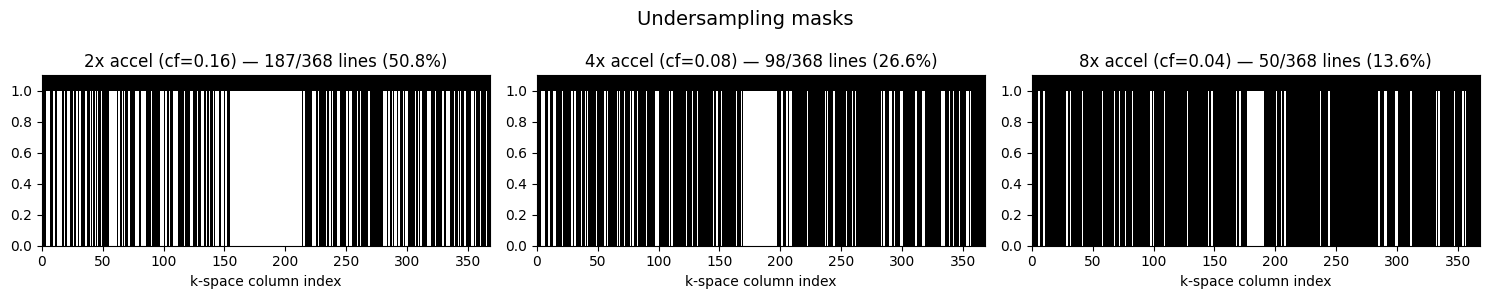

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
num_cols = kspace.shape[-1]

for ax, (acc, cf) in zip(axes, [(2, 0.16), (4, 0.08), (8, 0.04)]):
    mask = create_mask(num_cols, center_fraction=cf, acceleration=acc, seed=42)
    mask_2d = mask.squeeze().numpy()
    
    ax.bar(range(num_cols), mask_2d, width=1.0, color='white', edgecolor='none')
    ax.set_facecolor('black')
    ax.set_xlim(0, num_cols)
    ax.set_ylim(0, 1.1)
    kept = mask_2d.sum()
    ax.set_title(f'{acc}x accel (cf={cf}) — {kept:.0f}/{num_cols} lines ({100*kept/num_cols:.1f}%)')
    ax.set_xlabel('k-space column index')

plt.suptitle('Undersampling masks', fontsize=14)
plt.tight_layout()
plt.show()

## 1.7 Compare multiple volumes

Look at middle slices from different patient scans to understand data diversity.

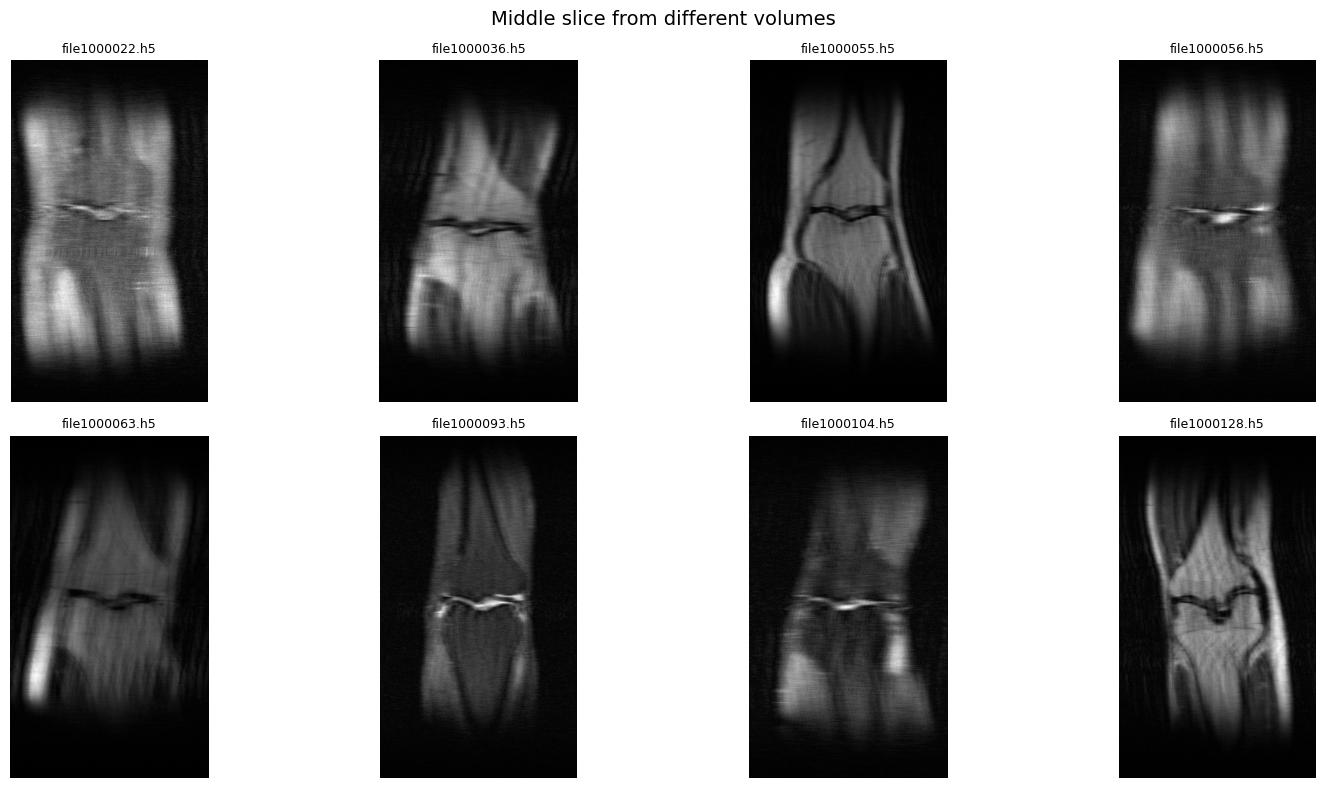

In [11]:
n_vols = min(8, len(files))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, f in zip(axes.flat, files[:n_vols]):
    with h5py.File(f, 'r') as hf:
        ks = hf['kspace'][hf['kspace'].shape[0] // 2]
    img = np.abs(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(ks))))
    ax.imshow(img, cmap='gray')
    ax.set_title(f.name[:15], fontsize=9)
    ax.axis('off')

plt.suptitle('Middle slice from different volumes', fontsize=14)
plt.tight_layout()
plt.show()

## 1.8 Intensity statistics

Understanding the distribution of pixel values helps with normalization decisions.

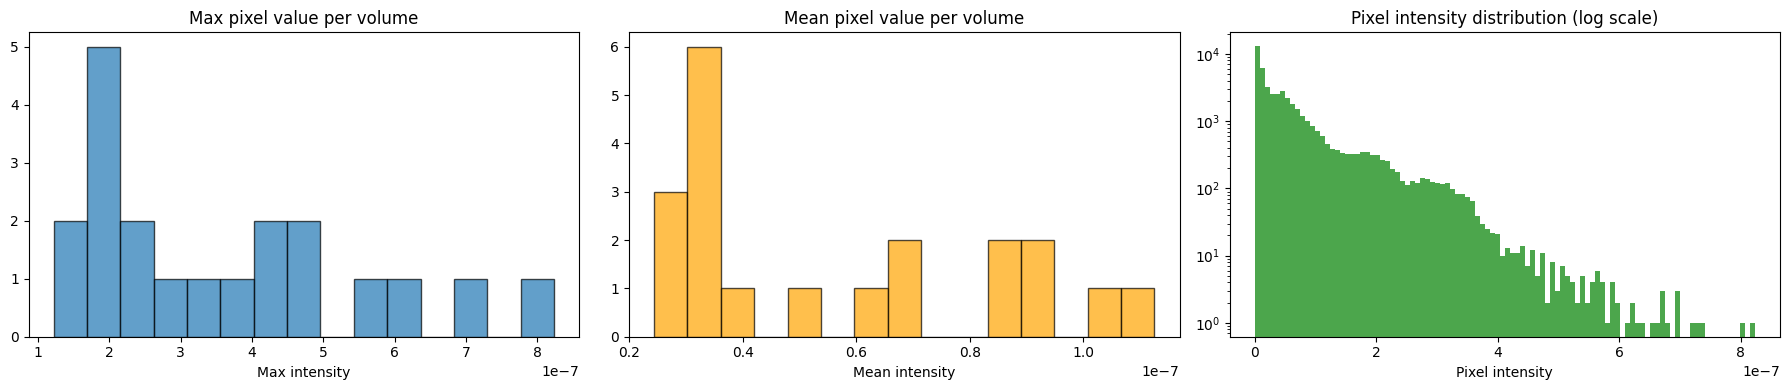

In [12]:
# Sample intensity values from several volumes
all_maxvals = []
all_meanvals = []
sample_pixels = []

for f in files[:20]:
    with h5py.File(f, 'r') as hf:
        ks = hf['kspace'][hf['kspace'].shape[0] // 2]
    img = np.abs(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(ks))))
    all_maxvals.append(img.max())
    all_meanvals.append(img.mean())
    sample_pixels.append(img.flatten()[::100])  # subsample

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(all_maxvals, bins=15, edgecolor='black', alpha=0.7)
axes[0].set_title('Max pixel value per volume')
axes[0].set_xlabel('Max intensity')

axes[1].hist(all_meanvals, bins=15, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Mean pixel value per volume')
axes[1].set_xlabel('Mean intensity')

all_px = np.concatenate(sample_pixels)
axes[2].hist(all_px, bins=100, edgecolor='none', alpha=0.7, color='green', log=True)
axes[2].set_title('Pixel intensity distribution (log scale)')
axes[2].set_xlabel('Pixel intensity')

plt.tight_layout()
plt.show()